# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Omar Walid Mohamed   
**Student ID:** 1210269

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [2]:
# Write your Data Pipeline code here
# 1. Load the file
df = pd.read_csv('kidney_disease.csv')

# Pre-step: Clean and isolate the target variable before dropping strings
df = df.dropna(subset=['classification'])
df['classification'] = df['classification'].astype(str).str.strip().map({'ckd': 1, 'notckd': 0})
df = df.dropna(subset=['classification'])

# Pre-step: Fix Kaggle's messy columns (which have hidden '?' or '\t' making them strings)
for col in ['pcv', 'wc', 'rc']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('?', np.nan), errors='coerce')

# 2. Drop all categorical (string) columns and the 'id' column
df = df.drop('id', axis=1, errors='ignore')
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numerical_cols]

# 3. Handle missing values (NaNs) by imputing the median
df = df.fillna(df.median())

# Separate features (X) and target (y)
X = df.drop('classification', axis=1)
y = df['classification']

# 5. Perform an 80/20 train/validation split (Stratified to keep class ratios balanced)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale the features to prevent data leakage (Fit ONLY on training data, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Task 1 Complete.")
print(f"Training set shape:   {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")

Task 1 Complete.
Training set shape:   (320, 14)
Validation set shape: (80, 14)


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [9]:
model_A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="Model_A_Failure")

model_A.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.Recall(name="recall")])
model_A.summary()

print("Training Model A...")
history_A = model_A.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=150, batch_size=32, verbose=0)
print("Model A Done.")

Model: "Model_A_Failure"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Model A...
Model A Done.


## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [10]:
l2 = tf.keras.regularizers.l2

model_B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(16, kernel_regularizer=l2(0.01)),
    tf.keras.layers.LeakyReLU(negative_slope=0.01),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(8, kernel_regularizer=l2(0.01)),
    tf.keras.layers.LeakyReLU(negative_slope=0.01),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="Model_B_Clinical")

model_B.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.Recall(name="recall")])
model_B.summary()

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

print("Training Model B...")
history_B = model_B.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=150, batch_size=32, callbacks=[early_stop], verbose=0)
print("Model B Done.")

Model: "Model_B_Clinical"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

Training Model B...
Model B Done.


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

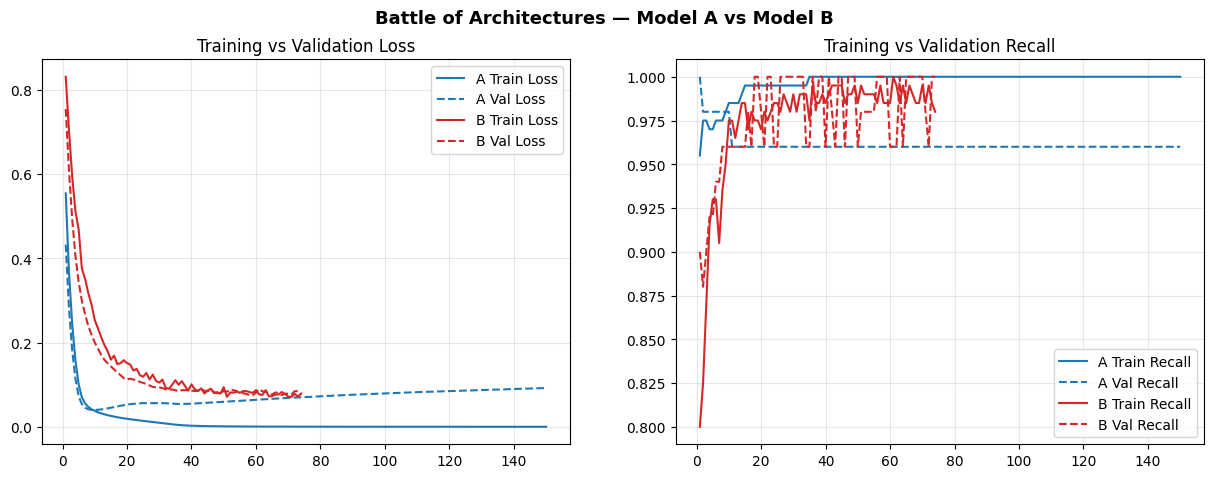

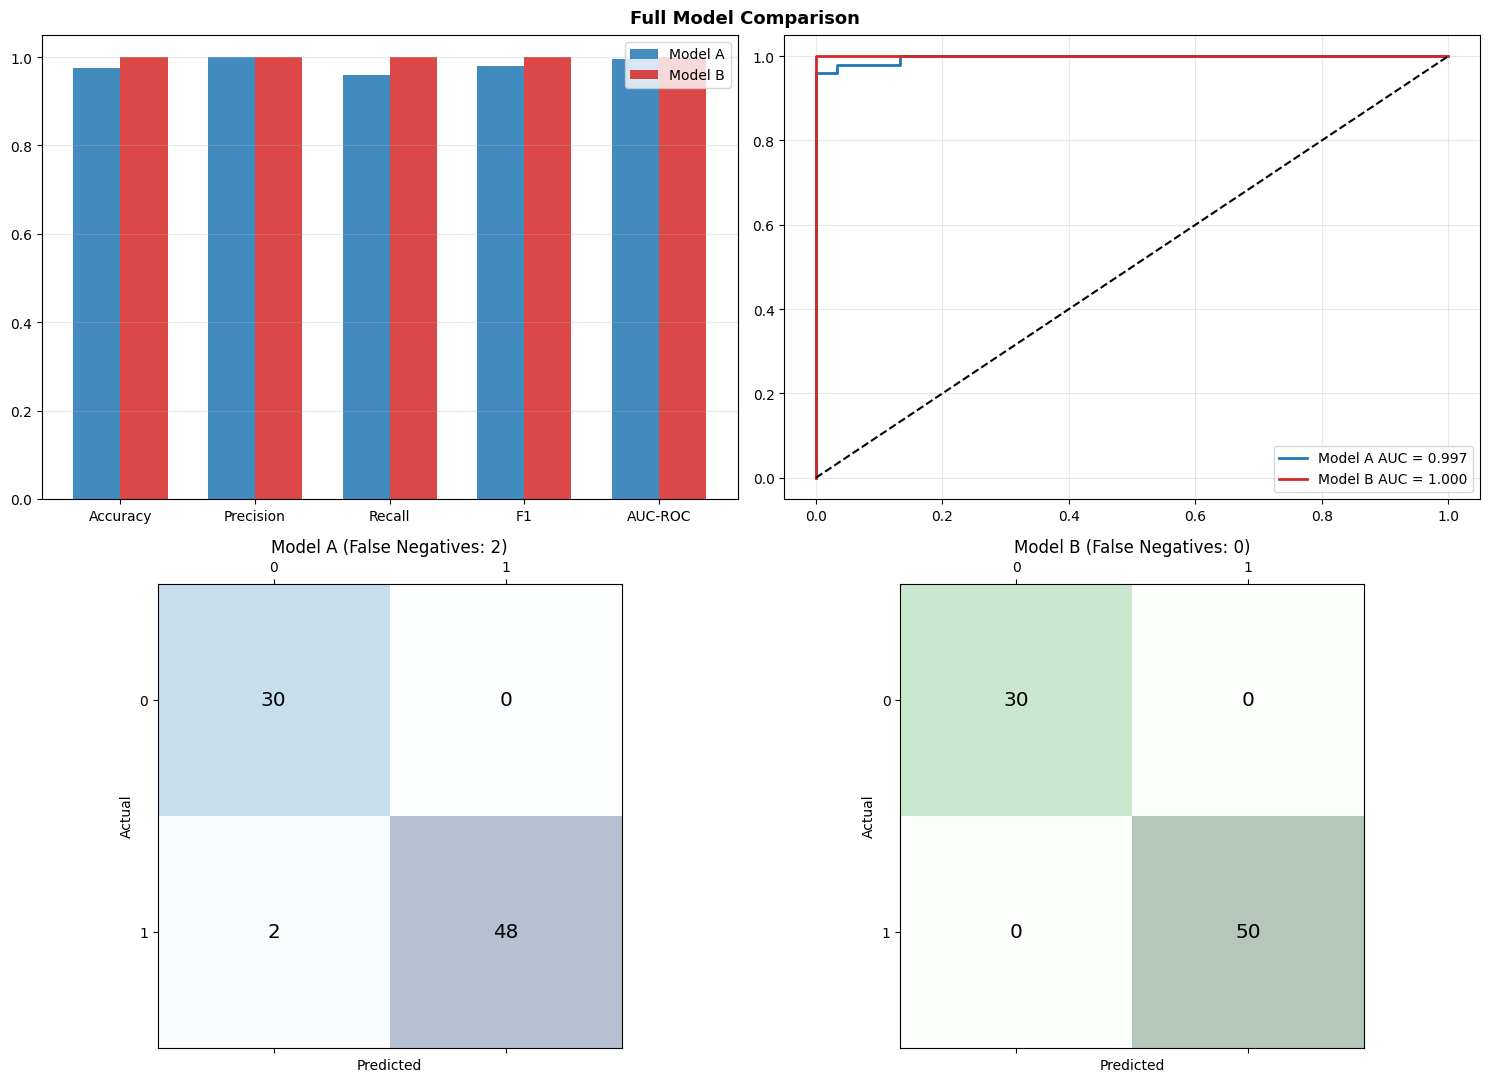

Model B Final Recall: 1.00


In [11]:
epochs_A = range(1, len(history_A.history["val_loss"]) + 1)
epochs_B = range(1, len(history_B.history["val_loss"]) + 1)

# --- 1. Training Curves (1x2 Plot) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Battle of Architectures — Model A vs Model B", fontsize=13, fontweight="bold")

axes[0].plot(epochs_A, history_A.history["loss"], label="A Train Loss", color="#1f77b4")
axes[0].plot(epochs_A, history_A.history["val_loss"], label="A Val Loss", color="#1f77b4", linestyle="--")
axes[0].plot(epochs_B, history_B.history["loss"], label="B Train Loss", color="#d62728")
axes[0].plot(epochs_B, history_B.history["val_loss"], label="B Val Loss", color="#d62728", linestyle="--")
axes[0].set_title("Training vs Validation Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_A, history_A.history["recall"], label="A Train Recall", color="#1f77b4")
axes[1].plot(epochs_A, history_A.history["val_recall"], label="A Val Recall", color="#1f77b4", linestyle="--")
axes[1].plot(epochs_B, history_B.history["recall"], label="B Train Recall", color="#d62728")
axes[1].plot(epochs_B, history_B.history["val_recall"], label="B Val Recall", color="#d62728", linestyle="--")
axes[1].set_title("Training vs Validation Recall"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.show()

# --- 2. Advanced Metrics & Confusion Matrices (2x2 Plot) ---
y_pred_A_prob = model_A.predict(X_val_scaled, verbose=0).ravel()
y_pred_B_prob = model_B.predict(X_val_scaled, verbose=0).ravel()
y_pred_A, y_pred_B = (y_pred_A_prob >= 0.5).astype(int), (y_pred_B_prob >= 0.5).astype(int)

fpr_A, tpr_A, _ = roc_curve(y_val, y_pred_A_prob)
fpr_B, tpr_B, _ = roc_curve(y_val, y_pred_B_prob)
auc_A, auc_B = auc(fpr_A, tpr_A), auc(fpr_B, tpr_B)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Full Model Comparison", fontsize=13, fontweight="bold")

# Bar Chart
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
vals_A = [accuracy_score(y_val, y_pred_A), precision_score(y_val, y_pred_A), recall_score(y_val, y_pred_A), f1_score(y_val, y_pred_A), auc_A]
vals_B = [accuracy_score(y_val, y_pred_B), precision_score(y_val, y_pred_B), recall_score(y_val, y_pred_B), f1_score(y_val, y_pred_B), auc_B]
x = np.arange(len(metrics))

axes[0, 0].bar(x - 0.175, vals_A, 0.35, label="Model A", color="#1f77b4", alpha=0.85)
axes[0, 0].bar(x + 0.175, vals_B, 0.35, label="Model B", color="#d62728", alpha=0.85)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(metrics); axes[0, 0].legend(); axes[0, 0].grid(axis="y", alpha=0.3)

# ROC Curves
axes[0, 1].plot(fpr_A, tpr_A, color="#1f77b4", lw=2, label=f"Model A AUC = {auc_A:.3f}")
axes[0, 1].plot(fpr_B, tpr_B, color="#d62728", lw=2, label=f"Model B AUC = {auc_B:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Confusion Matrix A
cm_A = confusion_matrix(y_val, y_pred_A)
axes[1, 0].matshow(cm_A, cmap=plt.cm.Blues, alpha=0.3)
for i in range(2):
    for j in range(2): axes[1, 0].text(j, i, str(cm_A[i, j]), ha="center", va="center", size="x-large")
axes[1, 0].set_title(f"Model A (False Negatives: {cm_A[1,0]})"); axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Actual")

# Confusion Matrix B
cm_B = confusion_matrix(y_val, y_pred_B)
axes[1, 1].matshow(cm_B, cmap=plt.cm.Greens, alpha=0.3)
for i in range(2):
    for j in range(2): axes[1, 1].text(j, i, str(cm_B[i, j]), ha="center", va="center", size="x-large")
axes[1, 1].set_title(f"Model B (False Negatives: {cm_B[1,0]})"); axes[1, 1].set_xlabel("Predicted"); axes[1, 1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print(f"Model B Final Recall: {recall_score(y_val, y_pred_B):.2f}")

### Mathematical Justification
**Final Parameter Count of Engineered Model: 385

**Explanation:** By actively restricting the network architecture to 385 total trainable parameters—which is fewer than the 400 available patient records in the dataset—and heavily penalising large feature-weights via L2 regularisation and Dropout, the model is mathematically deprived of the capacity required to memorise data noise; therefore, it is forced to isolate and learn only the most dominant, generalisable clinical markers of CKD.